In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from ast import literal_eval
from collections import defaultdict
import pickle
import random
import matplotlib.pyplot as plt
import shap

import torch
import torch.nn.functional as F
from torch.nn import init

from sklearn.ensemble import RandomForestRegressor
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

In [2]:

# Define the directory path
directory_path = '../data/raw/'

# Load data
sms_data = pd.read_csv(f'{directory_path}train/train_sms.csv')
voc_data = pd.read_csv(f'{directory_path}train/train_voc.csv')
dataset = pd.read_csv('../data/processed/processed_dataset.csv')

/var/folders/3c/t2jl0gwn1p731dmykyzxz5cw0000gn/T/ipykernel_73169/3612316307.py:6: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  voc_data = pd.read_csv(f'{directory_path}train/train_voc.csv')


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)  # If using GPU
    torch.cuda.manual_seed_all(seed)  # If using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # For reproducibility

set_seed(42)

In [4]:
# Load and preprocess data
df = dataset.copy()

# Extract labels and features
labels = df[['phone_no_m', 'label']]
features = df.drop(columns=['label'])

# # List of columns to drop
columns_to_drop = [
    'voc_dayname_mode_count',
    'sms_dayname_mode_count',
    'flow_sum',
    'call_county_unique',
    'voc_hour_mode_count',
    'sms_day_mode_count'
]

# # Drop them from the features DataFrame
features = features.drop(columns=columns_to_drop)

# Identify numerical features (after dropping)
numerical_features = features.columns.difference(['phone_no_m', 'imei_list'])

# Store the numerical features as a list
numerical_features = numerical_features.tolist()

# Standardize numerical features
standard_scaler = StandardScaler()
features[numerical_features] = standard_scaler.fit_transform(
    features[numerical_features].fillna(0)
)

# Create node features matrix
node_features = features[numerical_features].values
node_ids = features['phone_no_m'].values
num_nodes = len(node_ids)

# Create mapping from phone number to node index
phone_to_idx = {phone: idx for idx, phone in enumerate(node_ids)}

# Create labels array (aligned with node indices)
labels_array = labels.set_index('phone_no_m')['label'].reindex(node_ids).values

# After creating node_features
import torch
import torch.nn as nn

# Convert node features to tensor
node_features_tensor = torch.FloatTensor(node_features)

# Create feature embedding layer (optional)
class FeatureEmbedder(nn.Module):
    def __init__(self, input_dim, embedding_dim):
        super(FeatureEmbedder, self).__init__()
        self.embedding = nn.Sequential(
            nn.Linear(input_dim, embedding_dim),
            nn.ReLU()
        )
    
    def forward(self, x):
        return self.embedding(x)

# If you want fixed embeddings:
feature_dim = node_features.shape[1]
embedding_dim = feature_dim  # Keep same dimension or change as needed
feature_embedder = FeatureEmbedder(feature_dim, embedding_dim)
embedded_features = feature_embedder(node_features_tensor)

# Convert embedded features to numpy and save
embedded_features_np = embedded_features.detach().cpu().numpy()
np.save('node_features.npy', embedded_features_np)  # Overwrite original features

# Save the embedder for later use
torch.save(feature_embedder.state_dict(), 'feature_embedder.pt')

# Save embedded features
torch.save(embedded_features, 'embedded_features.pt')

In [5]:
#################################### Create Relation 1: Similarity Graph ####################################

# Compute similarity graph (cosine similarity)
similarity_matrix = cosine_similarity(features[numerical_features])
similarity_df = pd.DataFrame(similarity_matrix, index=df["phone_no_m"], columns=df["phone_no_m"])

# Map phone numbers to indices for quick lookup
phone_to_index = {phone: idx for idx, phone in enumerate(node_ids)}

k_nearest_neighbours = 15 ## change to 10,15,20,50

# Initialize relation graph (adjacency matrix)
adj_matrix1 = np.zeros((num_nodes, num_nodes))

for i, phone1 in enumerate(df["phone_no_m"]):
    # Step 0: Get all similarities (excluding self)
    similarities = [
        (j, similarity_matrix[i, j])
        for j in range(len(df["phone_no_m"])) if i != j
    ]
    
    positive = sorted([p for p in similarities], key=lambda x: x[1], reverse=True)

    # Select neighbors based strictly on k-nearest neighbours
    selected = []
    selected += positive[:k_nearest_neighbours+1]

    # Update adjacency matrix
    for neighbor_idx, sim in selected:
        neighbor = df["phone_no_m"].iloc[neighbor_idx]
        j = phone_to_index[neighbor]
        adj_matrix1[i, j] = sim
        adj_matrix1[j, i] = sim  # Symmetric matrix

# Remove self-loops
np.fill_diagonal(adj_matrix1, 0) 

# Convert adjacency matrix to sparse matrix
adj_matrix1_sparse = sp.csr_matrix(adj_matrix1)

In [6]:
#################################### relation 2 (calls and sms) #######################################

combined_data = pd.concat([voc_data[["phone_no_m", "opposite_no_m"]], sms_data[["phone_no_m", "opposite_no_m"]]])

# Group by 'phone_no_m' and create a set of unique 'opposite_no_m' values
grouped_data = combined_data.groupby("phone_no_m")["opposite_no_m"].apply(set).reset_index()

# Create a dictionary for quick lookup of opposite_no_m sets
opposite_dict = dict(zip(grouped_data["phone_no_m"], grouped_data["opposite_no_m"]))

# Find phone_no_m values that:
# (1) Appear in another phone_no_m's opposite_no_m list
# (2) Share common opposite_no_m contacts
def find_phone_in_opposite(phone, opposite_dict):
    linked_phones = set()
    
    for other_phone, opposite_set in opposite_dict.items():
        if phone == other_phone:
            continue  # Skip itself
        
        # Condition 1: phone appears in another's opposite list
        if phone in opposite_set:
            linked_phones.add(other_phone)
        
        # # Condition 2: Shared opposite contacts
        # if opposite_dict[phone] & opposite_set:  # Intersection check
        #     linked_phones.add(other_phone)

    return list(linked_phones)

# Apply the function to each phone_no_m
grouped_data["phone_in_opposite"] = grouped_data["phone_no_m"].apply(lambda phone: find_phone_in_opposite(phone, opposite_dict))
adj_matrix2 = np.zeros((num_nodes, num_nodes), dtype=int)

# Convert grouped_data into a dictionary
phone_graph = dict(zip(grouped_data["phone_no_m"], grouped_data["phone_in_opposite"]))

# Build adjacency matrix using phone mappings
for phone, connected_phones in phone_graph.items():
    if phone not in phone_to_index:
        continue
    u = phone_to_index[phone]  # Convert phone_no_m to index
    for other_phone in connected_phones:
        if other_phone in phone_to_index:
            v = phone_to_index[other_phone]
            adj_matrix2[u, v] = 1
            adj_matrix2[v, u] = 1  # Undirected graph

# Convert to sparse matrix
adj_matrix2_sparse = sp.csr_matrix(adj_matrix2)

In [7]:
#################################### Create Relation 3: Shared IMEI Graph (as sparse matrix) ####################################

df_cleaned = dataset[["phone_no_m", "imei_list"]].dropna(subset=['imei_list']) # changed this to use dataset to drop it from df
df_cleaned["imei_list"] = df_cleaned["imei_list"].fillna("")
df_cleaned["imei_list"] = df_cleaned["imei_list"].apply(
    lambda x: literal_eval(x) if isinstance(x, str) else x
)
df_exploded = df_cleaned.explode('imei_list')

# Group by IMEI and create edges
imei_groups = df_exploded.groupby('imei_list')['phone_no_m'].apply(list)
adj_matrix3 = np.zeros((num_nodes, num_nodes), dtype=int)
for phones in imei_groups:
    phone_indices = [phone_to_index[phone] for phone in phones if phone in phone_to_index]
    for i in range(len(phone_indices)):
        for j in range(i+1, len(phone_indices)):
            u, v = phone_indices[i], phone_indices[j]
            adj_matrix3[u, v] += 1
            adj_matrix3[v, u] += 1

adj_matrix3 = (adj_matrix3 > 0).astype(int)
adj_matrix3_sparse = sp.csr_matrix(adj_matrix3)

In [8]:
# Save adjacency lists
def sparse_to_adjlist(sp_matrix, filename):
    adj_lists = defaultdict(set)
    edges = sp_matrix.nonzero()
    for u, v in zip(edges[0], edges[1]):
        adj_lists[u].add(v)
    with open(filename, 'wb') as f:
        pickle.dump(adj_lists, f)

sparse_to_adjlist(adj_matrix1_sparse, 'adj_list_similarity.pkl')
sparse_to_adjlist(adj_matrix2_sparse, 'adj_list_calls.pkl')
sparse_to_adjlist(adj_matrix3_sparse, 'adj_list_imei.pkl')

# Save embedded features and labels
embedded_features_np = embedded_features.detach().cpu().numpy()
np.save('node_features.npy', embedded_features_np)
np.save('labels.npy', labels_array)


# Create train/val/test splits
train_idx, test_idx = train_test_split(
    range(num_nodes), test_size=0.2, stratify=labels_array, random_state=42 # ensures that the class distribution is preserved (stratify).
)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.2, stratify=labels_array[train_idx], random_state=42
)

np.save('train_idx.npy', train_idx)
np.save('val_idx.npy', val_idx)
np.save('test_idx.npy', test_idx)


In [9]:
def evaluate(model, features, labels, mask):
    model.eval()
    with torch.no_grad():
        logits, _ = model(mask.tolist())
        preds = torch.argmax(logits, dim=1)
        acc = (preds == labels[mask]).float().mean().item()
        prob = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        auc = roc_auc_score(labels[mask].cpu().numpy(), prob)
    return acc, auc, preds.cpu().numpy()

def load_data():
    adj_lists = []
    for rel in ['similarity', 'calls', 'imei']:
        with open(f'adj_list_{rel}.pkl', 'rb') as f:
            adj_lists.append(pickle.load(f))
    
    # Load precomputed embedded features
    features = np.load('node_features.npy')  # Now contains embedded features
    features = torch.FloatTensor(features)
    
    labels = torch.LongTensor(np.load('labels.npy'))
    train_idx = np.load('train_idx.npy')
    val_idx = np.load('val_idx.npy')
    test_idx = np.load('test_idx.npy')
    
    return adj_lists, features, labels, train_idx, val_idx, test_idx

In [10]:
class IntraAgg(nn.Module):
    """Intra-relation aggregator"""
    def __init__(self, features, feat_dim, cuda=False):
        super(IntraAgg, self).__init__()
        self.features = features
        self.feat_dim = feat_dim
        self.cuda = cuda

    def forward(self, nodes, to_neighs, num_sample=10):
        _set = set
        samp_neighs = []
        for to_neigh in to_neighs:
            if num_sample is not None and len(to_neigh) >= num_sample:
                samp_neighs.append(set(random.sample(list(to_neigh), num_sample)))
            else:
                samp_neighs.append(set(to_neigh))

        unique_nodes = list(set.union(*samp_neighs)) if samp_neighs else []
        unique_nodes = {n:i for i, n in enumerate(unique_nodes)}
        mask = torch.zeros(len(samp_neighs), len(unique_nodes))
        row_indices = []
        col_indices = []
        for i, neigh in enumerate(samp_neighs):
            row_indices.extend([i]*len(neigh))
            col_indices.extend([unique_nodes[n] for n in neigh if n in unique_nodes])
        mask[row_indices, col_indices] = 1
        if self.cuda:
            mask = mask.cuda()
        num_neigh = mask.sum(1, keepdim=True)
        num_neigh[num_neigh == 0] = 1  # Avoid division by zero
        mask = mask / num_neigh
        if not unique_nodes:
            embed_matrix = torch.zeros((0, self.feat_dim), device=mask.device)
        else:
            embed_matrix = self.features[torch.LongTensor(list(unique_nodes.keys()))]
        to_feats = mask @ embed_matrix
        return to_feats

relation_weights_global = []

class InterAgg(nn.Module):
    """Inter-relation aggregator for 3 relations"""
    def __init__(self, features, adj_lists, intraggs, cuda=False):
        super(InterAgg, self).__init__()
        self.features = features
        self.adj_lists = adj_lists
        self.intra_agg1 = intraggs[0]
        self.intra_agg2 = intraggs[1]
        self.intra_agg3 = intraggs[2]
        self.feat_dim = features.shape[1]
        self.cuda = cuda
        
        # RL module only
        self.rl_module = nn.Sequential(
            nn.Linear(4 * self.feat_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )
        
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.xavier_uniform_(m.weight)

    def forward(self, nodes, adj_lists=None, train_flag=True):
        if adj_lists is None:
            adj_lists = self.adj_lists  # Use default if not provided
        to_neighs1 = [adj_lists[0][int(n)] for n in nodes]
        to_neighs2 = [adj_lists[1][int(n)] for n in nodes]
        to_neighs3 = [adj_lists[2][int(n)] for n in nodes]

        embed1 = self.intra_agg1(nodes, to_neighs1)
        embed2 = self.intra_agg2(nodes, to_neighs2)
        embed3 = self.intra_agg3(nodes, to_neighs3)

        self_feats = self.features[torch.LongTensor(nodes)]
        concat_feats = torch.cat([self_feats, embed1, embed2, embed3], dim=1)

        scores = self.rl_module(concat_feats)
        weights = F.softmax(scores, dim=1)
        relation_weights_global.append(weights.cpu().detach().numpy())

        combined = (
            weights[:, 0].unsqueeze(1) * embed1 +
            weights[:, 1].unsqueeze(1) * embed2 +
            weights[:, 2].unsqueeze(1) * embed3
        )

        # Return raw combined features without classification layers
        combined_features = torch.cat([self_feats, combined], dim=1)
        return combined_features, scores  # Only return features and relation scores

class CARE(nn.Module):
    def __init__(self, num_classes, inter, lambda_1, class_weights, features, hidden_dim=64, num_layers=2):
        super(CARE, self).__init__()
        self.embedder = FeatureEmbedder(feature_dim, embedding_dim)
        self.features = features
        self.inter = inter
        self.xent = nn.CrossEntropyLoss(weight=class_weights)
        self.lambda_1 = lambda_1
        self.num_layers = num_layers
        
        # Input dimension is 2 * original feature dimension
        self.input_dim = 2 * self.inter.feat_dim
        
        # Main classification layers
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(self.input_dim, hidden_dim))
        for _ in range(num_layers-2):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.layers.append(nn.Linear(hidden_dim, num_classes))
        
        # Auxiliary classification layer
        self.aux_layer = nn.Linear(self.input_dim, num_classes)
        
        for m in self.layers:
            if isinstance(m, nn.Linear):
                init.xavier_uniform_(m.weight)
        init.xavier_uniform_(self.aux_layer.weight)

    def forward(self, nodes):
        # Get features from InterAgg
        raw_features = self.features[nodes]
        embedded = self.embedder(raw_features)
        combined_features, _ = self.inter(nodes)
        
        # Main task processing
        x = combined_features
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
            x = F.dropout(x, training=self.training)
        main_scores = self.layers[-1](x)
        
        # Auxiliary task
        aux_scores = self.aux_layer(combined_features)
        
        return main_scores, aux_scores

    def loss(self, nodes, labels):
        main_scores, aux_scores = self.forward(nodes)
        main_loss = self.xent(main_scores, labels)
        aux_loss = self.xent(aux_scores, labels)
        return main_loss + self.lambda_1 * aux_loss

In [ ]:
# 1. Define the config
config = {
  "hidden_dim": 64,
  "lambda_1": 0.5,
  "lr": 0.05,
  "num_layers": 2,
  "weight_decay": 5e-05
}

# 2. Modified CARE Class with 2 Layers
class CARE(nn.Module):
    def __init__(self, num_classes, inter, lambda_1, class_weights, features, hidden_dim=64, num_layers=4, dropout_rate=0.4):
        super(CARE, self).__init__()
        self.inter = inter
        self.embedder = FeatureEmbedder(feature_dim, embedding_dim)
        self.features = features
        self.xent = nn.CrossEntropyLoss(weight=class_weights)
        self.lambda_1 = lambda_1
        self.input_dim = 2 * self.inter.feat_dim
        self.dropout_rate = dropout_rate

        self.layers = nn.ModuleList([
            nn.Linear(self.input_dim, hidden_dim),
            *[nn.Linear(hidden_dim, hidden_dim) for _ in range(num_layers - 2)],
            nn.Linear(hidden_dim, num_classes)
        ])
        
        self.aux_layer = nn.Linear(self.input_dim, num_classes)
        
        for m in self.layers:
            init.xavier_uniform_(m.weight)
        init.xavier_uniform_(self.aux_layer.weight)

    def forward(self, nodes):
        combined_features, _ = self.inter(nodes)
        x = combined_features

        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
            x = F.dropout(x, p=self.dropout_rate, training=self.training)

        main_scores = self.layers[-1](x)
        aux_scores = self.aux_layer(combined_features)
        return main_scores, aux_scores

    def loss(self, nodes, labels):
        main_scores, aux_scores = self.forward(nodes)
        return self.xent(main_scores, labels) + self.lambda_1 * self.xent(aux_scores, labels)

# 3. Training Setup with Parameters
def train_final_model(patience=25):
    adj_lists, features, labels, train_idx, val_idx, test_idx = load_data()
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    features, labels = features.to(device), labels.to(device)
    
    class_weights = compute_class_weight(
        'balanced', 
        classes=np.unique(labels.cpu().numpy()),
        y=labels.cpu().numpy()
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float, device=device)

    intra1 = IntraAgg(features, features.shape[1])
    intra2 = IntraAgg(features, features.shape[1])
    intra3 = IntraAgg(features, features.shape[1])
    inter = InterAgg(features, adj_lists, [intra1, intra2, intra3])

    model = CARE(2, inter,
                lambda_1=config['lambda_1'],
                class_weights=class_weights,
                hidden_dim=config['hidden_dim'],
                features = features,
                num_layers=config['num_layers'],
                dropout_rate=0.5).to(device)
    
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay']
    )

    best_auc = 0
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        loss = model.loss(train_idx, labels[train_idx])
        loss.backward()
        optimizer.step()

        val_acc, val_auc, _ = evaluate(model, features, labels, val_idx)

        print(f'Epoch {epoch+1}: Loss: {loss.item():.4f} | Val AUC: {val_auc:.4f}')

        if val_auc > best_auc:
            best_auc = val_auc
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

    if best_model_state:
        model.load_state_dict(best_model_state)

    test_acc, test_auc, test_preds = evaluate(model, features, labels, test_idx)
    print(f'\nFinal Test AUC: {test_auc:.4f}')
    print(classification_report(labels[test_idx].cpu().numpy(), test_preds))

    return model

# 4. Save and Use the Model
final_model = train_final_model()

Epoch 1: Loss: 1.1880 | Val AUC: 0.8504
Epoch 2: Loss: 1.7610 | Val AUC: 0.8688
Epoch 3: Loss: 0.8588 | Val AUC: 0.8476
Epoch 4: Loss: 0.8378 | Val AUC: 0.8569
Epoch 5: Loss: 0.8327 | Val AUC: 0.8723
Epoch 6: Loss: 0.7132 | Val AUC: 0.8839
Epoch 7: Loss: 0.6366 | Val AUC: 0.8945
Epoch 8: Loss: 0.6039 | Val AUC: 0.8985
Epoch 9: Loss: 0.5953 | Val AUC: 0.9010
Epoch 10: Loss: 0.5738 | Val AUC: 0.9027
Epoch 11: Loss: 0.5730 | Val AUC: 0.9040
Epoch 12: Loss: 0.5679 | Val AUC: 0.9058
Epoch 13: Loss: 0.5731 | Val AUC: 0.9078
Epoch 14: Loss: 0.5525 | Val AUC: 0.9096
Epoch 15: Loss: 0.5534 | Val AUC: 0.9110
Epoch 16: Loss: 0.5425 | Val AUC: 0.9120
Epoch 17: Loss: 0.5332 | Val AUC: 0.9131
Epoch 18: Loss: 0.5310 | Val AUC: 0.9140
Epoch 19: Loss: 0.5270 | Val AUC: 0.9153
Epoch 20: Loss: 0.5230 | Val AUC: 0.9163
Epoch 21: Loss: 0.5166 | Val AUC: 0.9172
Epoch 22: Loss: 0.5200 | Val AUC: 0.9183
Epoch 23: Loss: 0.5118 | Val AUC: 0.9190
Epoch 24: Loss: 0.4998 | Val AUC: 0.9200
Epoch 25: Loss: 0.5037 | 

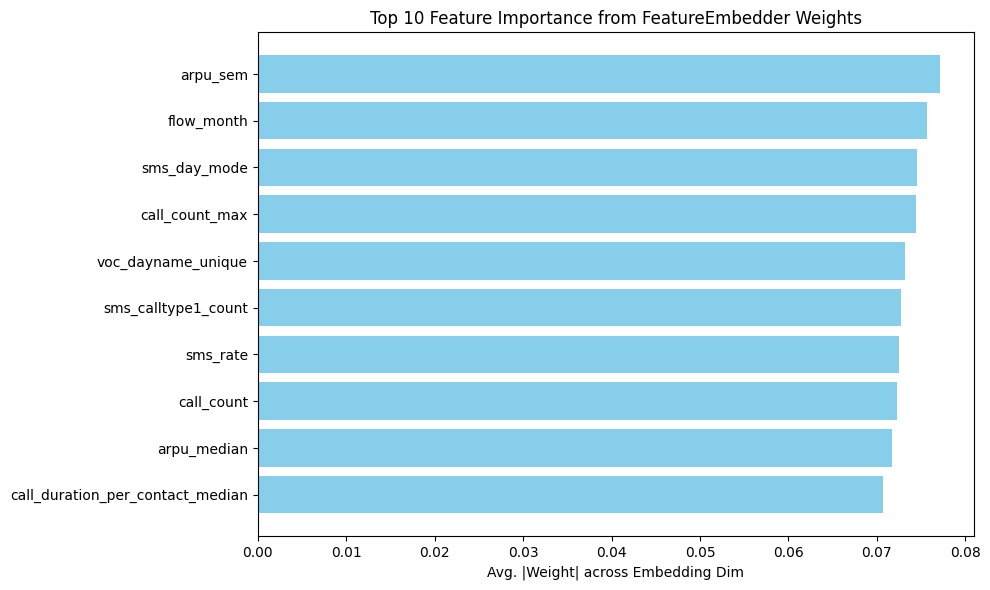

In [ ]:
# Extract the weight matrix from the Linear layer
embedder_weights = final_model.embedder.embedding[0].weight.detach().cpu().numpy()

# Compute average absolute weight per input feature
feature_importance = np.mean(np.abs(embedder_weights), axis=0)

# Combine feature names and importance into a list of tuples
feature_tuples = list(zip(numerical_features, feature_importance))

# Sort by importance (descending)
sorted_features = sorted(feature_tuples, key=lambda x: x[1], reverse=True)
sorted_names, sorted_importance = zip(*sorted_features)

# Show top 10 features
top_10_names = sorted_names[:10]
top_10_importance = sorted_importance[:10]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_names, top_10_importance, color='skyblue')
plt.xlabel("Avg. |Weight| across Embedding Dim")
plt.title("Top 10 Feature Importance from FeatureEmbedder Weights")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.show()


In [14]:
# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reload data
adj_lists, features, labels, train_idx, val_idx, test_idx = load_data()
features, labels = features.to(device), labels.to(device)

# Recompute class weights (optional, not used in inference but required to init model)
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(labels.cpu().numpy()),
    y=labels.cpu().numpy()
)
class_weights = torch.tensor(class_weights, dtype=torch.float, device=device)

# Rebuild inter-aggregator
intra1 = IntraAgg(features, features.shape[1])
intra2 = IntraAgg(features, features.shape[1])
intra3 = IntraAgg(features, features.shape[1])
inter = InterAgg(features, adj_lists, [intra1, intra2, intra3])

# Rebuild model architecture
model = CARE(
    num_classes=2,
    inter=inter,
    lambda_1=config['lambda_1'],
    class_weights=class_weights,
    hidden_dim=config['hidden_dim'],
    num_layers=config['num_layers'],
    dropout_rate=0.5,
    features =features
).to(device)

# Load saved state dict
model.load_state_dict(torch.load('final_care_model.pth', map_location=device))

# Set model to evaluation mode
model.eval()


CARE(
  (inter): InterAgg(
    (intra_agg1): IntraAgg()
    (intra_agg2): IntraAgg()
    (intra_agg3): IntraAgg()
    (rl_module): Sequential(
      (0): Linear(in_features=232, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=3, bias=True)
    )
  )
  (embedder): FeatureEmbedder(
    (embedding): Sequential(
      (0): Linear(in_features=58, out_features=58, bias=True)
      (1): ReLU()
    )
  )
  (xent): CrossEntropyLoss()
  (layers): ModuleList(
    (0): Linear(in_features=116, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
  (aux_layer): Linear(in_features=116, out_features=2, bias=True)
)

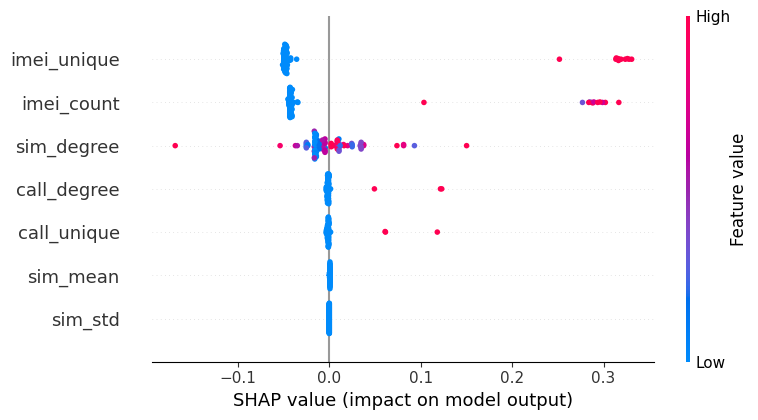

In [ ]:
# CARE returns logits; apply softmax to get probabilities
with torch.no_grad():
    logits_train, _ = model(train_idx)
    probs_train = F.softmax(logits_train, dim=1)[:, 1].cpu().numpy()  # probability of class 1

    logits_test, _ = model(test_idx)
    probs_test = F.softmax(logits_test, dim=1)[:, 1].cpu().numpy()

# Convert to class labels using threshold 0.5
y_train_care_pred_class = (probs_train > 0.5).astype(int)
y_test_care_pred_class = (probs_test > 0.5).astype(int)

def create_relation_features(adj_mats, node_ids):
    """Create relational features for each node from adjacency matrices"""
    features = []
    
    for i, node in enumerate(node_ids):
        # Relation 1: Similarity graph features
        # FIX: Use [0] instead of [1] for 1D array indices
        sim_connections = np.nonzero(adj_mats[0][i])[0]
        sim_feats = [
            len(sim_connections),
            adj_mats[0][i].toarray()[0][sim_connections].mean() if len(sim_connections) > 0 else 0,
            adj_mats[0][i].toarray()[0][sim_connections].std() if len(sim_connections) > 0 else 0
        ]

        
        # Relation 2: Call/SMS graph features
        call_connections = np.nonzero(adj_mats[1][i])[0]
        call_feats = [
            len(call_connections),
            len(np.unique(call_connections)) if len(call_connections) > 0 else 0
        ]
        
        # Relation 3: IMEI graph features
        imei_connections = np.nonzero(adj_mats[2][i])[0]
        imei_feats = [
            len(imei_connections),
            len(np.unique(imei_connections)) if len(imei_connections) > 0 else 0
        ]
        
        features.append(sim_feats + call_feats + imei_feats)
    
    columns = [
        'sim_degree', 'sim_mean', 'sim_std',
        'call_degree', 'call_unique',
        'imei_count', 'imei_unique'
    ]
    return pd.DataFrame(features, columns=columns)

# Create relational features DataFrame
adj_mats = [adj_matrix1_sparse, adj_matrix2_sparse, adj_matrix3_sparse]
relation_df = create_relation_features(adj_mats, node_ids)

# Prepare data splits using original indices
X_train = relation_df.iloc[train_idx].values
X_test = relation_df.iloc[test_idx].values
y_train = labels_array[train_idx]
y_test = labels_array[test_idx]

# Sample a subset for efficiency
sample_idx = np.random.choice(len(X_test), 100, replace=False)
X_sample = X_test[sample_idx]  # Make sure this is a NumPy array if X_test is not a DataFrame

# Train RF to mimic CARE probabilities
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, probs_train)

# Predict probabilities with RF
rf_probs_test = rf.predict(X_test)

# Convert to class labels using 0.5 threshold
rf_pred_class = (rf_probs_test > 0.5).astype(int)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)
feature_names = relation_df.columns.tolist()

# Select SHAP values for the positive class
if isinstance(shap_values, list) and len(shap_values) > 1:
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

if shap_values_to_plot.ndim == 3:
    shap_values_to_plot = shap_values_to_plot[:, :, 1]

# Plot SHAP summary
shap.summary_plot(shap_values_to_plot, X_sample, feature_names=feature_names)
